# Notebook 2 — Tests statistiques
## Projet 9 — Analyse des comportements clients de la librairie Lapage

---

### Contexte
Suite du notebook 1. Julie (Business Intelligence Analyst) souhaite
comprendre le comportement des clients BtoC en ligne pour le comparer
à la connaissance acquise via les librairies physiques.

### Objectif
Tester 5 corrélations statistiques sur la base clients BtoC
pour valider ou invalider des hypothèses comportementales.

### Source des données
`df_final.csv` produit par le notebook 1 — 687 534 lignes × 12 colonnes.

### Les 5 corrélations testées
| # | Variables | Type | Test choisi |
|---|---|---|---|
| 1 | Genre × Catégorie | Quali × Quali | Chi² + V de Cramér |
| 2 | Âge × Montant total | Quanti × Quanti | Spearman |
| 3 | Âge × Fréquence d'achat | Quanti × Quanti | Spearman |
| 4 | Âge × Panier moyen | Quanti × Quanti | Spearman |
| 5 | Âge × Catégorie | Quanti × Quali | Kruskal-Wallis |

## Glossaire des tests statistiques

### Tests de normalité
- **Shapiro-Wilk** ⭐ — Vérifie si une distribution est normale. Utilisé avant de choisir entre Pearson/Spearman et ANOVA/Kruskal-Wallis.
- **Kolmogorov-Smirnov** — Alternative à Shapiro pour très grands échantillons. Non utilisé ici.

### Variables qualitatives × qualitatives
- **Chi²** ⭐ — Teste l'indépendance entre deux variables qualitatives.
- **V de Cramér** ⭐ — Mesure la force du lien après un Chi². De 0 (aucun lien) à 1 (lien parfait).
- **Fisher** — Alternative au Chi² pour petits effectifs (< 5). Non utilisé ici.

### Variables quantitatives × quantitatives
- **Pearson** — Corrélation entre deux variables normales. Non utilisé ici (distributions non-normales).
- **Spearman** ⭐ — Corrélation entre deux variables non-normales. Alternative à Pearson.
- **Kendall** — Alternative à Spearman pour très petits échantillons. Non utilisé ici.

### Variables quantitatives × qualitatives (3 groupes+)
- **Levene** ⭐ — Vérifie l'égalité des variances entre groupes. Utilisé avant ANOVA.
- **ANOVA** — Compare les moyennes de 3 groupes ou plus. Non utilisé ici (conditions non remplies).
- **Kruskal-Wallis** ⭐ — Alternative non-paramétrique à l'ANOVA. Utilisé quand Shapiro ❌ ou Levene ❌.

### Variables quantitatives × qualitatives (2 groupes)
- **Student (t-test)** — Compare les moyennes de 2 groupes. Non utilisé ici.
- **Mann-Whitney** — Alternative non-paramétrique au Student. Non utilisé ici.

> ⭐ = utilisé dans ce projet

## 1. Imports des librairies

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from scipy.stats import chi2_contingency, shapiro, spearmanr, levene, kruskal, f_oneway

# Paramètres d'affichage
pd.set_option('display.max_columns', None)
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (12, 5)

## 2. Chargement des données

On repart du fichier exporté par le notebook 1.

In [2]:
import os

DATA_PATH = os.path.join(os.getcwd(), "data", "processed", "df_final.csv")

df = pd.read_csv(DATA_PATH, sep=";")

print("Shape :", df.shape)
print("\nColonnes :", df.columns.tolist())
print("\nTypes :\n", df.dtypes)

Shape : (687534, 12)

Colonnes : ['id_prod', 'date', 'session_id', 'client_id', 'price', 'categ', 'sex', 'birth', 'age', 'mois', 'annee', 'categ_label']

Types :
 id_prod         object
date            object
session_id      object
client_id       object
price          float64
categ            int64
sex             object
birth            int64
age              int64
mois            object
annee            int64
categ_label     object
dtype: object


In [3]:
df['date'] = pd.to_datetime(df['date'])

print("Type date :", df['date'].dtype)
print("Aperçu :")
display(df.head())

Type date : datetime64[ns]
Aperçu :


,id_prod,date,session_id,client_id,price,categ,sex,birth,age,mois,annee,categ_label
0,0_1259,2021-03-01 00:01:07.843138,s_1,c_329,11.99,0,f,1967,54,2021-03,2021,Catégorie 0
1,0_1390,2021-03-01 00:02:26.047414,s_2,c_664,19.37,0,m,1960,61,2021-03,2021,Catégorie 0
2,0_1352,2021-03-01 00:02:38.311413,s_3,c_580,4.50,0,m,1988,33,2021-03,2021,Catégorie 0
3,0_1458,2021-03-01 00:04:54.559692,s_4,c_7912,6.55,0,f,1989,32,2021-03,2021,Catégorie 0
4,0_1358,2021-03-01 00:05:18.801198,s_5,c_2033,16.49,0,f,1956,65,2021-03,2021,Catégorie 0


## 3. Suppression des clients BtoB

On retire les 4 clients atypiques identifiés dans le notebook 1
(CA > 100 000 €) car leur comportement d'achat est radicalement
différent des clients BtoC et fausserait les tests statistiques.

In [4]:
# Liste des clients BtoB
btob_ids = ['c_1609', 'c_4958', 'c_6714', 'c_3454']

# Suppression
df_btoc = df[~df['client_id'].isin(btob_ids)].copy()

print(f"Dataframe complet   : {df.shape[0]:,} lignes")
print(f"Dataframe sans BtoB : {df_btoc.shape[0]:,} lignes")
print(f"Lignes supprimées   : {df.shape[0] - df_btoc.shape[0]:,}")

Dataframe complet   : 687,534 lignes
Dataframe sans BtoB : 640,734 lignes
Lignes supprimées   : 46,800


## 4. Tests statistiques

### 4.1 Test 1 — Genre × Catégorie (Chi² + V de Cramér)

**Variables :** genre (qualitative) × catégorie (qualitative)
**Question :** Le genre d'un client influence-t-il la catégorie de livres achetés ?

**Choix du test :** Chi² — deux variables qualitatives → on teste leur indépendance.

**H0 :** Le genre et la catégorie achetée sont indépendants.
**H1 :** Il existe un lien entre le genre et la catégorie achetée.

**Condition :** effectifs théoriques ≥ 5 dans chaque case du tableau.

In [5]:
# Une ligne par client — catégorie la plus achetée
clients = df_btoc.groupby('client_id').agg(
    sex=('sex', 'first'),
    categ_principale=('categ', lambda x: x.mode()[0])
).reset_index()

# Tableau de contingence
contingency_table = pd.crosstab(clients['sex'], clients['categ_principale'])
print("Tableau de contingence :")
display(contingency_table)

# Test Chi²
chi2, p, dof, expected = chi2_contingency(contingency_table)
print(f"\nChi² : {chi2:.4f}")
print(f"p-value : {p:.4f}")
print(f"Degrés de liberté : {dof}")
print(f"\nEffectifs théoriques (min) : {expected.min():.1f} → condition ≥ 5 : {'✅' if expected.min() >= 5 else '❌'}")

# V de Cramér
n = contingency_table.sum().sum()
phi2 = chi2 / n
r, k = contingency_table.shape
phi2corr = max(0, phi2 - ((k-1)*(r-1))/(n-1))
rcorr = r - ((r-1)**2)/(n-1)
kcorr = k - ((k-1)**2)/(n-1)
v_cramer = np.sqrt(phi2corr / min((kcorr-1), (rcorr-1)))
print(f"\nV de Cramér : {v_cramer:.4f}")

# Interprétation
if p < 0.05:
    print("\np-value < 0.05 → On rejette H0")
    print("→ Il existe un lien significatif entre le genre et la catégorie achetée.")
else:
    print("\np-value > 0.05 → On ne rejette pas H0")
    print("→ Pas de lien significatif entre le genre et la catégorie achetée.")

Tableau de contingence :


categ_principale,0,1,2
sex,,,
f,2370,1608,500
m,2256,1385,477



Chi² : 4.8977
p-value : 0.0864
Degrés de liberté : 2

Effectifs théoriques (min) : 468.0 → condition ≥ 5 : ✅

V de Cramér : 0.0184

p-value > 0.05 → On ne rejette pas H0
→ Pas de lien significatif entre le genre et la catégorie achetée.


**Résultats :**
- Chi² = 4.90 | p-value = 0.086 > 0.05 → On ne rejette pas H0
- V de Cramér = 0.018 → lien quasi inexistant

**Interprétation :**
Le genre n'influence pas la catégorie de livres achetés.
Hommes et femmes achètent dans les mêmes proportions.

**Recommandation :**
Une campagne marketing ciblant une catégorie par genre
ne serait pas pertinente.

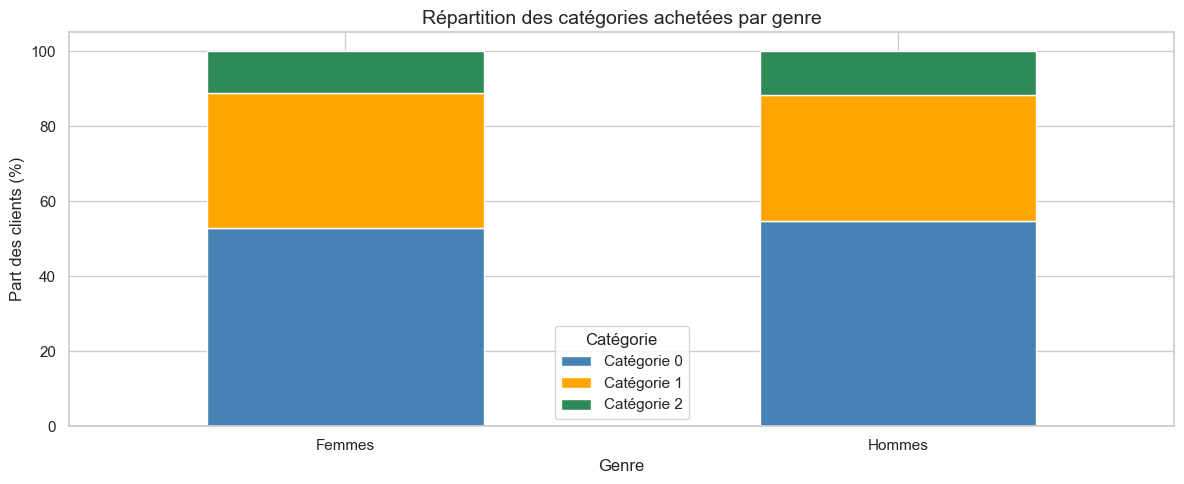

In [6]:
client_profile_pct = clients.groupby('sex')['categ_principale'].value_counts(normalize=True).unstack() * 100

fig, ax = plt.subplots()
client_profile_pct.plot(kind='bar', ax=ax,
                        color=['steelblue', 'orange', 'seagreen'],
                        width=0.5, edgecolor='white', stacked=True)
ax.set_title("Répartition des catégories achetées par genre", fontsize=14)
ax.set_xlabel("Genre")
ax.set_ylabel("Part des clients (%)")
ax.set_xticklabels(['Femmes', 'Hommes'], rotation=0)
ax.legend(title='Catégorie', labels=['Catégorie 0', 'Catégorie 1', 'Catégorie 2'])
plt.tight_layout()
plt.show()

### 4.2 Test 2 — Âge × Montant total des achats (Spearman)

**Variables :** âge (quantitative) × montant total (quantitative)
**Question :** Les clients plus âgés dépensent-ils plus ou moins ?

**Choix du test :** On vérifie d'abord la normalité avec Shapiro-Wilk.
- Si les deux variables sont normales → Pearson
- Sinon → Spearman

**H0 :** Pas de corrélation entre l'âge et le montant total.
**H1 :** Il existe une corrélation significative.

In [7]:
# Agrégation par client
client_stats = df_btoc.groupby('client_id').agg(
    age=('age', 'first'),
    montant_total=('price', 'sum')
).reset_index()

# Shapiro-Wilk
stat_age, p_age = shapiro(client_stats['age'].sample(5000, random_state=42))
stat_montant, p_montant = shapiro(client_stats['montant_total'].sample(5000, random_state=42))

print("=== Shapiro-Wilk ===")
print(f"Âge          : p={p_age:.6f} → {'normale ✅' if p_age > 0.05 else 'non-normale ❌'}")
print(f"Montant total : p={p_montant:.6f} → {'normale ✅' if p_montant > 0.05 else 'non-normale ❌'}")

# Spearman
corr, p_spearman = spearmanr(client_stats['age'], client_stats['montant_total'])
print(f"\n=== Spearman ===")
print(f"Coefficient ρ : {corr:.4f}")
print(f"p-value       : {p_spearman:.6f}")

if p_spearman < 0.05:
    print(f"\n✅ p-value < 0.05 → Corrélation significative")
    print(f"→ Lien {'positif' if corr > 0 else 'négatif'} entre l'âge et le montant total.")
else:
    print("\n❌ p-value > 0.05 → Pas de corrélation significative")

=== Shapiro-Wilk ===
Âge          : p=0.000000 → non-normale ❌
Montant total : p=0.000000 → non-normale ❌

=== Spearman ===
Coefficient ρ : -0.1847
p-value       : 0.000000

✅ p-value < 0.05 → Corrélation significative
→ Lien négatif entre l'âge et le montant total.


**Résultats :**
- Shapiro-Wilk : distributions non-normales ❌ → Spearman choisi
- ρ = -0.18 | p-value = 0.000 < 0.05 → Corrélation significative

**Interprétation :**
Corrélation négative faible — les clients plus âgés dépensent
légèrement moins au total. Le lien existe mais est faible.
L'âge n'est pas le facteur principal expliquant le montant dépensé.

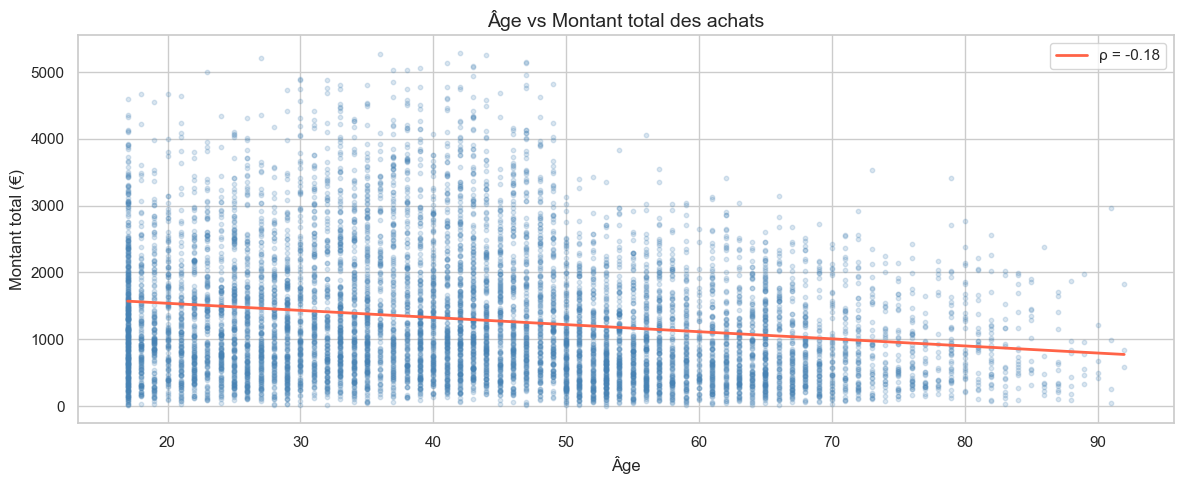

In [8]:
fig, ax = plt.subplots()
ax.scatter(client_stats['age'], client_stats['montant_total'],
           alpha=0.2, s=10, color='steelblue')

z = np.polyfit(client_stats['age'], client_stats['montant_total'], 1)
p = np.poly1d(z)
x_line = np.linspace(client_stats['age'].min(), client_stats['age'].max(), 100)
ax.plot(x_line, p(x_line), color='tomato', linewidth=2, label=f'ρ = -0.18')

ax.set_title("Âge vs Montant total des achats", fontsize=14)
ax.set_xlabel("Âge")
ax.set_ylabel("Montant total (€)")
ax.legend()
plt.tight_layout()
plt.show()

### 4.3 Test 3 — Âge × Fréquence d'achat (Spearman)

**Variables :** âge (quantitative) × fréquence d'achat (quantitative)
**Question :** Les clients plus âgés achètent-ils plus ou moins souvent ?

**Choix du test :** Shapiro-Wilk d'abord → Spearman si non-normale.

**H0 :** Pas de corrélation entre l'âge et la fréquence d'achat.
**H1 :** Il existe une corrélation significative.

In [9]:
# Agrégation par client
client_freq = df_btoc.groupby('client_id').agg(
    age=('age', 'first'),
    frequence=('session_id', 'count')
).reset_index()

# Shapiro-Wilk
stat_age, p_age = shapiro(client_freq['age'].sample(5000, random_state=42))
stat_freq, p_freq = shapiro(client_freq['frequence'].sample(5000, random_state=42))

print("=== Shapiro-Wilk ===")
print(f"Âge       : p={p_age:.6f} → {'normale ✅' if p_age > 0.05 else 'non-normale ❌'}")
print(f"Fréquence : p={p_freq:.6f} → {'normale ✅' if p_freq > 0.05 else 'non-normale ❌'}")

# Spearman
corr, p_spearman = spearmanr(client_freq['age'], client_freq['frequence'])
print(f"\n=== Spearman ===")
print(f"Coefficient ρ : {corr:.4f}")
print(f"p-value       : {p_spearman:.6f}")

if p_spearman < 0.05:
    print(f"\n✅ p-value < 0.05 → Corrélation significative")
    print(f"→ Lien {'positif' if corr > 0 else 'négatif'} entre l'âge et la fréquence d'achat.")
else:
    print("\n❌ p-value > 0.05 → Pas de corrélation significative")

=== Shapiro-Wilk ===
Âge       : p=0.000000 → non-normale ❌
Fréquence : p=0.000000 → non-normale ❌

=== Spearman ===
Coefficient ρ : 0.1275
p-value       : 0.000000

✅ p-value < 0.05 → Corrélation significative
→ Lien positif entre l'âge et la fréquence d'achat.


**Résultats :**
- Shapiro-Wilk : distributions non-normales ❌ → Spearman choisi
- ρ = +0.13 | p-value = 0.000 < 0.05 → Corrélation significative

**Interprétation :**
Corrélation positive très faible — les clients plus âgés achètent
légèrement plus souvent.

**Insight croisé avec le Test 2 :**
Les seniors achètent plus fréquemment (ρ = +0.13) mais dépensent
moins au total (ρ = -0.18) → ils font de petits achats réguliers.
Stratégie recommandée : programmes de fidélité ciblant les seniors.

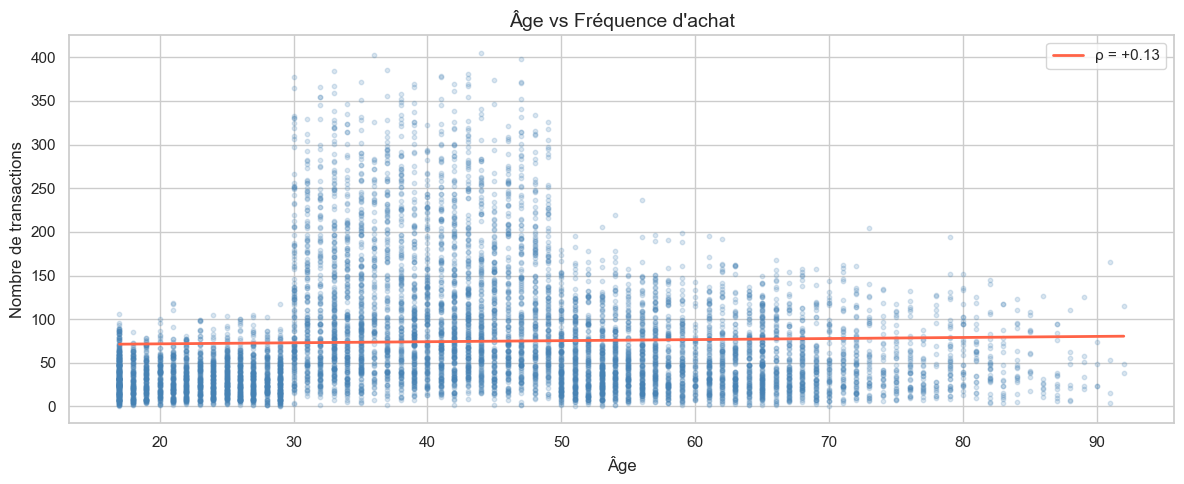

In [10]:
fig, ax = plt.subplots()
ax.scatter(client_freq['age'], client_freq['frequence'],
           alpha=0.2, s=10, color='steelblue')

z = np.polyfit(client_freq['age'], client_freq['frequence'], 1)
p = np.poly1d(z)
x_line = np.linspace(client_freq['age'].min(), client_freq['age'].max(), 100)
ax.plot(x_line, p(x_line), color='tomato', linewidth=2, label=f'ρ = +0.13')

ax.set_title("Âge vs Fréquence d'achat", fontsize=14)
ax.set_xlabel("Âge")
ax.set_ylabel("Nombre de transactions")
ax.legend()
plt.tight_layout()
plt.show()

### 4.4 Test 4 — Âge × Panier moyen (Spearman)

**Variables :** âge (quantitative) × panier moyen (quantitative)
**Question :** Les clients plus âgés ont-ils un panier moyen plus élevé ?

**Choix du test :** Shapiro-Wilk d'abord → Spearman si non-normale.

**H0 :** Pas de corrélation entre l'âge et le panier moyen.
**H1 :** Il existe une corrélation significative.

In [11]:
# Agrégation par client
client_panier = df_btoc.groupby('client_id').agg(
    age=('age', 'first'),
    montant_total=('price', 'sum'),
    nb_transactions=('session_id', 'count')
).reset_index()
client_panier['panier_moyen'] = client_panier['montant_total'] / client_panier['nb_transactions']

# Shapiro-Wilk
stat_age, p_age = shapiro(client_panier['age'].sample(5000, random_state=42))
stat_panier, p_panier = shapiro(client_panier['panier_moyen'].sample(5000, random_state=42))

print("=== Shapiro-Wilk ===")
print(f"Âge          : p={p_age:.6f} → {'normale ✅' if p_age > 0.05 else 'non-normale ❌'}")
print(f"Panier moyen : p={p_panier:.6f} → {'normale ✅' if p_panier > 0.05 else 'non-normale ❌'}")

# Spearman
corr, p_spearman = spearmanr(client_panier['age'], client_panier['panier_moyen'])
print(f"\n=== Spearman ===")
print(f"Coefficient ρ : {corr:.4f}")
print(f"p-value       : {p_spearman:.6f}")

if p_spearman < 0.05:
    print(f"\n✅ p-value < 0.05 → Corrélation significative")
    print(f"→ Lien {'positif' if corr > 0 else 'négatif'} entre l'âge et le panier moyen.")
else:
    print("\n❌ p-value > 0.05 → Pas de corrélation significative")

=== Shapiro-Wilk ===
Âge          : p=0.000000 → non-normale ❌
Panier moyen : p=0.000000 → non-normale ❌

=== Spearman ===
Coefficient ρ : -0.3259
p-value       : 0.000000

✅ p-value < 0.05 → Corrélation significative
→ Lien négatif entre l'âge et le panier moyen.


**Résultats :**
- Shapiro-Wilk : distributions non-normales ❌ → Spearman choisi
- ρ = -0.33 | p-value = 0.000 < 0.05 → Corrélation significative

**Interprétation :**
Corrélation négative modérée — la plus forte des 3 tests Spearman.
Plus le client est âgé, moins son panier moyen est élevé.
Les jeunes dépensent plus par achat mais achètent moins souvent.

**Insight croisé Tests 2, 3, 4 :**
| Profil | Fréquence | Panier moyen |
|---|---|---|
| Jeunes (< 30 ans) | Faible | Élevé |
| Seniors (> 50 ans) | Élevée | Faible |

Stratégie : offres gros panier pour les jeunes,
abonnements / fidélité pour les seniors.

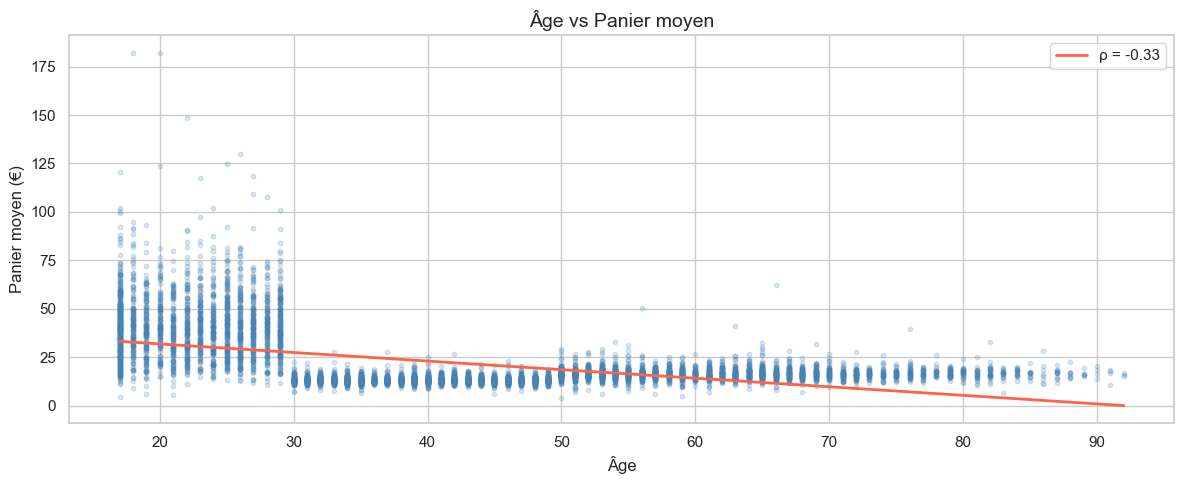

In [12]:
fig, ax = plt.subplots()
ax.scatter(client_panier['age'], client_panier['panier_moyen'],
           alpha=0.2, s=10, color='steelblue')

z = np.polyfit(client_panier['age'], client_panier['panier_moyen'], 1)
p = np.poly1d(z)
x_line = np.linspace(client_panier['age'].min(), client_panier['age'].max(), 100)
ax.plot(x_line, p(x_line), color='tomato', linewidth=2, label='ρ = -0.33')

ax.set_title("Âge vs Panier moyen", fontsize=14)
ax.set_xlabel("Âge")
ax.set_ylabel("Panier moyen (€)")
ax.legend()
plt.tight_layout()
plt.show()

### 4.5 Test 5 — Âge × Catégorie (Kruskal-Wallis)

**Variables :** âge (quantitative) × catégorie (qualitative — 3 groupes)
**Question :** L'âge des clients diffère-t-il selon la catégorie achetée ?

**Choix du test :** Shapiro-Wilk + Levene d'abord.
- Si normalité ✅ + variances égales ✅ → ANOVA
- Sinon → Kruskal-Wallis

**H0 :** L'âge médian est identique dans les 3 catégories.
**H1 :** L'âge médian diffère selon la catégorie achetée.

In [14]:
from scipy.stats import f_oneway

# Agrégation par client
client_categ = df_btoc.groupby('client_id').agg(
    age=('age', 'first'),
    categ_principale=('categ', lambda x: x.mode()[0])
).reset_index()

# Groupes
groupe_0 = client_categ[client_categ['categ_principale'] == 0]['age']
groupe_1 = client_categ[client_categ['categ_principale'] == 1]['age']
groupe_2 = client_categ[client_categ['categ_principale'] == 2]['age']

print("=== Statistiques par groupe ===")
for g, nom in zip([groupe_0, groupe_1, groupe_2], ['Catégorie 0', 'Catégorie 1', 'Catégorie 2']):
    print(f"{nom} : n={len(g)}, moyenne={g.mean():.1f} ans, std={g.std():.1f}")

# Shapiro-Wilk
print("\n=== Shapiro-Wilk par groupe ===")
for g, nom in zip([groupe_0, groupe_1, groupe_2], ['Catégorie 0', 'Catégorie 1', 'Catégorie 2']):
    stat, p = shapiro(g.sample(min(5000, len(g)), random_state=42))
    print(f"{nom} : p={p:.4f} → {'normale ✅' if p > 0.05 else 'non-normale ❌'}")

# Levene
stat_lev, p_lev = levene(groupe_0, groupe_1, groupe_2)
print(f"\n=== Levene ===")
print(f"p={p_lev:.4f} → {'variances égales ✅' if p_lev > 0.05 else 'variances inégales ❌'}")

# Kruskal-Wallis
stat_k, p_kruskal = kruskal(groupe_0, groupe_1, groupe_2)
print(f"\n=== Kruskal-Wallis ===")
print(f"H = {stat_k:.4f}, p = {p_kruskal:.4f}")
if p_kruskal < 0.05:
    print("✅ p < 0.05 → Différence significative entre les groupes")
else:
    print("❌ p > 0.05 → Pas de différence significative")

# ANOVA à titre indicatif
stat_f, p_anova = f_oneway(groupe_0, groupe_1, groupe_2)
print(f"\n=== ANOVA (à titre indicatif) ===")
print(f"F = {stat_f:.4f}, p = {p_anova:.4f}")

=== Statistiques par groupe ===
Catégorie 0 : n=4626, moyenne=42.5 ans, std=12.5
Catégorie 1 : n=2993, moyenne=49.6 ans, std=19.8
Catégorie 2 : n=977, moyenne=22.6 ans, std=4.3

=== Shapiro-Wilk par groupe ===
Catégorie 0 : p=0.0000 → non-normale ❌
Catégorie 1 : p=0.0000 → non-normale ❌
Catégorie 2 : p=0.0000 → non-normale ❌

=== Levene ===
p=0.0000 → variances inégales ❌

=== Kruskal-Wallis ===
H = 2003.5696, p = 0.0000
✅ p < 0.05 → Différence significative entre les groupes

=== ANOVA (à titre indicatif) ===
F = 1201.6197, p = 0.0000


**Résultats :**
- Shapiro-Wilk : non-normale dans les 3 groupes ❌
- Levene : variances inégales ❌
- Les deux conditions de l'ANOVA sont violées → Kruskal-Wallis choisi
- H = 2003.57 | p = 0.000 < 0.05 → Différence très significative

**Âge moyen par catégorie :**
| Catégorie | Âge moyen | Std | Interprétation |
|---|---|---|---|
| Catégorie 0 | 42.5 ans | 12.5 | Clientèle adulte homogène |
| Catégorie 1 | 49.6 ans | 19.8 | Tous âges, très dispersé |
| Catégorie 2 | 22.6 ans | 4.3 | Clientèle jeune ultra homogène |

**Insight majeur :**
La catégorie 2 est achetée quasi exclusivement par des 20-30 ans.
C'est le résultat le plus actionnable — ciblage marketing
très précis possible sur cette tranche d'âge.

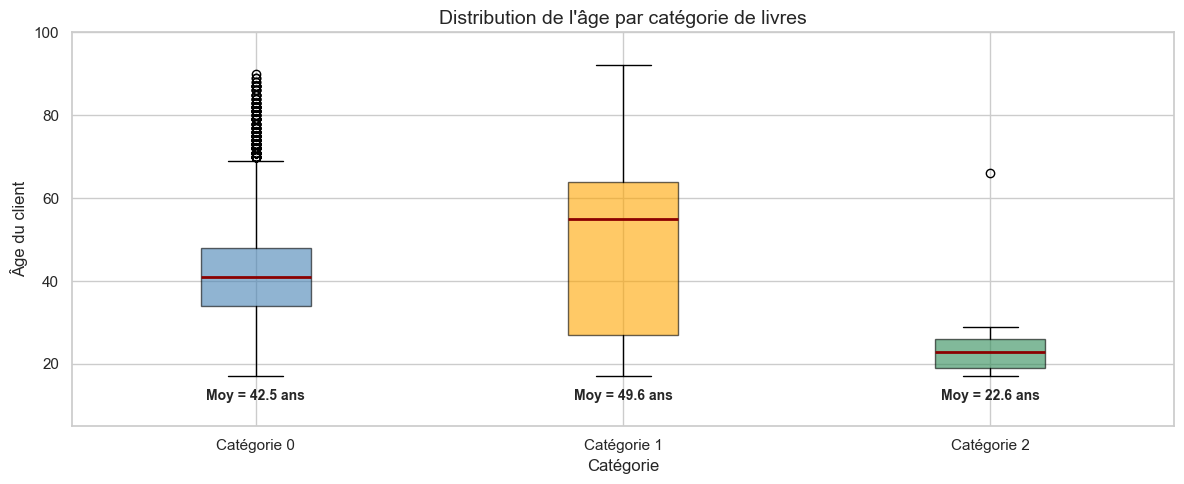

In [15]:
fig, ax = plt.subplots()

data_plot = [groupe_0, groupe_1, groupe_2]
bp = ax.boxplot(data_plot, tick_labels=['Catégorie 0', 'Catégorie 1', 'Catégorie 2'],
                patch_artist=True)

colors = ['steelblue', 'orange', 'seagreen']
for patch, color in zip(bp['boxes'], colors):
    patch.set_facecolor(color)
    patch.set_alpha(0.6)

for median in bp['medians']:
    median.set(color='darkred', linewidth=2)

ax.set_title("Distribution de l'âge par catégorie de livres", fontsize=14)
ax.set_xlabel("Catégorie")
ax.set_ylabel("Âge du client")
ax.set_ylim(bottom=5, top=100)

for i, g in enumerate(data_plot):
    bottom_whisker_y = bp['whiskers'][2 * i].get_ydata()[1]
    ax.text(i + 1, bottom_whisker_y - 3, f'Moy = {g.mean():.1f} ans',
            ha='center', va='top', fontsize=10, fontweight='bold')

plt.tight_layout()
plt.show()

## 5. Conclusion — Synthèse des tests statistiques

### Récapitulatif des 5 tests

| # | Corrélation | Test | Résultat | Interprétation |
|---|---|---|---|---|
| 1 | Genre × Catégorie | Chi² | p=0.086 ❌ | Pas de lien — genre non discriminant |
| 2 | Âge × Montant total | Spearman | ρ=-0.18 ✅ | Lien négatif faible |
| 3 | Âge × Fréquence | Spearman | ρ=+0.13 ✅ | Lien positif très faible |
| 4 | Âge × Panier moyen | Spearman | ρ=-0.33 ✅ | Lien négatif modéré |
| 5 | Âge × Catégorie | Kruskal-Wallis | H=2003 ✅ | Différence très significative |

### Synthèse comportement clients

L'âge est le facteur le plus discriminant — 3 profils se dégagent :

| Profil | Âge | Comportement | Stratégie |
|---|---|---|---|
| Jeunes | 18-30 ans | Gros panier, peu fréquent, catégorie 2 | Offres gros panier |
| Adultes | 30-50 ans | Comportement standard, catégorie 0 | Fidélisation classique |
| Seniors | 50+ ans | Fréquents, petits paniers, catégorie 1 | Abonnements / fidélité |

### Recommandation principale
Segmenter la stratégie marketing par âge — c'est le facteur
le plus discriminant identifié dans cette analyse.
Le genre ne doit pas être utilisé comme critère de ciblage.